In [ ]:
import os

print(os.getcwd())

c:\Users\Дима\Desktop\main imir\Python\CRM_new


In [17]:
excel_file = pd.ExcelFile(
    r"C:\Users\Дима\Desktop\main imir\Python\CRM_new\AdventureWorks Sales Sample.xlsx"
)

print(excel_file.sheet_names)

['Sales Order_data', 'Sales Territory_data', 'Sales_data', 'Reseller_data', 'Date_data', 'Product_data', 'Customer_data']


In [18]:
print(df.columns.tolist())

['Channel', 'SalesOrderLineKey', 'Sales Order', 'Sales Order Line']


In [19]:
for col in df.columns:
    print(col)

Channel
SalesOrderLineKey
Sales Order
Sales Order Line


In [20]:
import openpyxl

print(openpyxl.__version__)

3.1.5


In [21]:
import sys

print(sys.executable)

c:\Users\Дима\Desktop\main imir\venv\Scripts\python.exe


In [22]:
# ============================================================
# SalesFlow Analytics
# ETL & Dataset Initialization
# Korean Startup Style CRM Analytics
# ============================================================

# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# pastel style
plt.style.use("default")

# =========================
# DISPLAY SETTINGS
# =========================

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# =========================
# LOAD DATASET
# =========================

print("=" * 60)
print("Loading AdventureWorks Dataset")
print("=" * 60)

df = pd.read_excel(
    r"C:\Users\Дима\Desktop\main imir\Python\CRM_new\AdventureWorks Sales Sample.xlsx",
    sheet_name="Sales_data"
)

print("\nDataset Loaded Successfully")

Loading AdventureWorks Dataset



Dataset Loaded Successfully


In [23]:
# =========================
# BASIC OVERVIEW
# =========================

print("\n" + "=" * 60)
print("Dataset Overview")
print("=" * 60)

print("\nFirst 5 Rows:\n")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:\n")
print(df.columns)


Dataset Overview

First 5 Rows:

   SalesOrderLineKey  ResellerKey  CustomerKey  ProductKey  OrderDateKey  DueDateKey  ShipDateKey  SalesTerritoryKey  \
0           43659001          676           -1         349      20170702    20170712   20170709.0                  5   
1           43659002          676           -1         350      20170702    20170712   20170709.0                  5   
2           43659003          676           -1         351      20170702    20170712   20170709.0                  5   
3           43659004          676           -1         344      20170702    20170712   20170709.0                  5   
4           43659005          676           -1         345      20170702    20170712   20170709.0                  5   

   Order Quantity  Unit Price  Extended Amount  Unit Price Discount Pct  Product Standard Cost  Total Product Cost  \
0               1    2024.994         2024.994                        0              1898.0944           1898.0944   
1        

In [24]:
# =========================
# DATA TYPES
# =========================

print("\n" + "=" * 60)
print("Data Types")
print("=" * 60)

print(df.dtypes)


Data Types
SalesOrderLineKey            int64
ResellerKey                  int64
CustomerKey                  int64
ProductKey                   int64
OrderDateKey                 int64
DueDateKey                   int64
ShipDateKey                float64
SalesTerritoryKey            int64
Order Quantity               int64
Unit Price                 float64
Extended Amount            float64
Unit Price Discount Pct      int64
Product Standard Cost      float64
Total Product Cost         float64
Sales Amount               float64
dtype: object


In [25]:
# =========================
# MISSING VALUES
# =========================

print("\n" + "=" * 60)
print("Missing Values")
print("=" * 60)

missing_values = df.isnull().sum()

print(missing_values)


Missing Values
SalesOrderLineKey             0
ResellerKey                   0
CustomerKey                   0
ProductKey                    0
OrderDateKey                  0
DueDateKey                    0
ShipDateKey                2113
SalesTerritoryKey             0
Order Quantity                0
Unit Price                    0
Extended Amount               0
Unit Price Discount Pct       0
Product Standard Cost         0
Total Product Cost            0
Sales Amount                  0
dtype: int64


In [26]:
# =========================
# DESCRIPTIVE STATISTICS
# =========================

print("\n" + "=" * 60)
print("Descriptive Statistics")
print("=" * 60)

print(df.describe())


Descriptive Statistics


       SalesOrderLineKey    ResellerKey    CustomerKey     ProductKey  OrderDateKey    DueDateKey   ShipDateKey  \
count       1.212530e+05  121253.000000  121253.000000  121253.000000  1.212530e+05  1.212530e+05  1.191400e+05   
mean        5.782642e+07     170.043430    9384.833868     424.884094  2.019158e+07  2.019183e+07  2.019159e+07   
std         9.009990e+06     224.536697   10171.582167     116.978898  7.981850e+03  8.021172e+03  7.990125e+03   
min         4.365900e+07      -1.000000      -1.000000     212.000000  2.017070e+07  2.017071e+07  2.017071e+07   
25%         4.987905e+07      -1.000000      -1.000000     339.000000  2.019041e+07  2.019042e+07  2.019041e+07   
50%         5.702800e+07       3.000000      -1.000000     470.000000  2.019101e+07  2.019102e+07  2.019101e+07   
75%         6.549000e+07     327.000000   18116.000000     528.000000  2.020022e+07  2.020030e+07  2.020022e+07   
max         7.512300e+07     701.000000   29483.000000     606.000000  2.020062e

In [27]:
# =========================
# KPI OVERVIEW
# =========================

total_sales = df["Sales Amount"].sum()

total_orders = len(df)

unique_customers = df["CustomerKey"].nunique()

average_sales = df["Sales Amount"].mean()

print("\n" + "=" * 60)
print("Sales KPI Overview")
print("=" * 60)

print(f"\nTotal Revenue: ${total_sales:,.2f}")

print(f"Total Orders: {total_orders:,}")

print(f"Unique Customers: {unique_customers:,}")

print(f"Average Sales Amount: ${average_sales:,.2f}")


Sales KPI Overview

Total Revenue: $109,809,274.20
Total Orders: 121,253
Unique Customers: 18,485
Average Sales Amount: $905.62


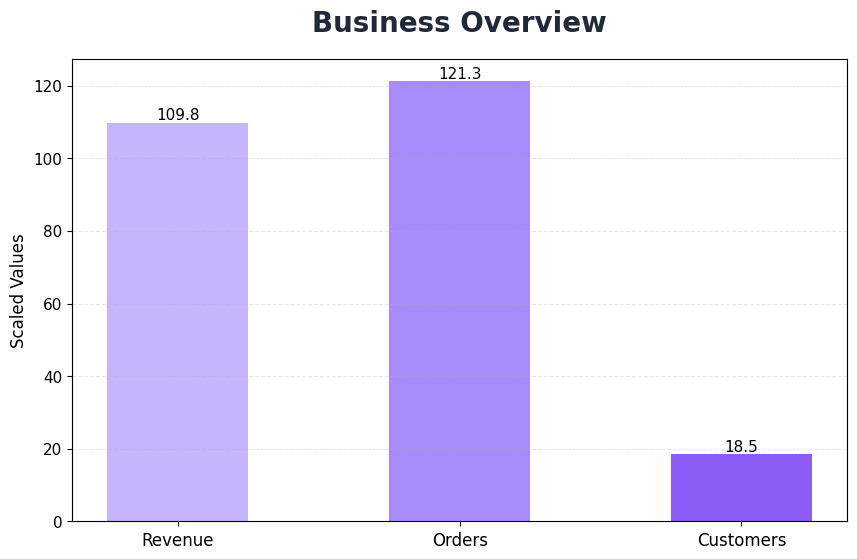

In [28]:
# =========================
# SIMPLE KPI VISUALIZATION
# =========================

kpi_names = [
    "Revenue",
    "Orders",
    "Customers"
]

kpi_values = [
    total_sales / 1000000,
    total_orders / 1000,
    unique_customers / 1000
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    kpi_names,
    kpi_values,
    color=["#C4B5FD", "#A78BFA", "#8B5CF6"],
    width=0.5
)

plt.title(
    "Business Overview",
    fontsize=20,
    fontweight="bold",
    color="#1F2937",
    pad=20
)

plt.ylabel("Scaled Values", fontsize=12)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=11)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.show()

In [29]:
# =========================
# BUSINESS INSIGHTS
# =========================

print("\n" + "=" * 60)
print("Initial Business Insights")
print("=" * 60)

print("""
1. The dataset contains large-scale customer sales activity.

2. Multiple regions and product categories are included.

3. Sales behavior can be analyzed from a CRM perspective.

4. The dataset is suitable for:
   - customer analysis
   - sales forecasting
   - purchase prediction
   - regional trend analysis
""")


Initial Business Insights

1. The dataset contains large-scale customer sales activity.

2. Multiple regions and product categories are included.

3. Sales behavior can be analyzed from a CRM perspective.

4. The dataset is suitable for:
   - customer analysis
   - sales forecasting
   - purchase prediction
   - regional trend analysis



In [30]:
# =========================
# ETL COMPLETED
# =========================

print("\n" + "=" * 60)
print("ETL Initialization Completed")
print("=" * 60)


ETL Initialization Completed
